Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

Load and Preprocess Data

In [2]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Use smaller subset for speed
X_train = X_train[:500]
y_train = y_train[:500]

X_test = X_test[:100]
y_test = y_test[:100]

# Reshape to (batch, channel, height, width)
X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

print("Training shape:", X_train.shape)

Training shape: (500, 1, 28, 28)


Convolution Layer

In [3]:
class ConvLayer:
    def __init__(self, num_filters, filter_size):
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.filters = np.random.randn(num_filters, filter_size, filter_size) / 9

    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h - self.filter_size + 1):
            for j in range(w - self.filter_size + 1):
                region = image[i:i+self.filter_size, j:j+self.filter_size]
                yield region, i, j

    def forward(self, input):
        self.last_input = input
        h, w = input.shape
        output = np.zeros((self.num_filters, h - 2, w - 2))

        for f in range(self.num_filters):
            for region, i, j in self.iterate_regions(input):
                output[f, i, j] = np.sum(region * self.filters[f])

        return output

    def backward(self, d_L_d_out, learning_rate):
        d_L_d_filters = np.zeros(self.filters.shape)

        for f in range(self.num_filters):
            for region, i, j in self.iterate_regions(self.last_input):
                d_L_d_filters[f] += d_L_d_out[f, i, j] * region

        self.filters -= learning_rate * d_L_d_filters

ReLU

In [4]:
class ReLU:
    def forward(self, input):
        self.last_input = input
        return np.maximum(0, input)

    def backward(self, d_L_d_out):
        return d_L_d_out * (self.last_input > 0)

Max Pooling

In [5]:
class MaxPool:
    def iterate_regions(self, image):
        h, w = image.shape
        for i in range(h // 2):
            for j in range(w // 2):
                region = image[(i*2):(i*2+2), (j*2):(j*2+2)]
                yield region, i, j

    def forward(self, input):
        self.last_input = input
        h, w = input.shape
        output = np.zeros((h//2, w//2))

        for region, i, j in self.iterate_regions(input):
            output[i, j] = np.max(region)

        return output

    def backward(self, d_L_d_out):
        d_L_d_input = np.zeros(self.last_input.shape)

        for region, i, j in self.iterate_regions(self.last_input):
            h, w = region.shape
            max_val = np.max(region)

            for i2 in range(h):
                for j2 in range(w):
                    if region[i2, j2] == max_val:
                        d_L_d_input[i*2+i2, j*2+j2] = d_L_d_out[i, j]

        return d_L_d_input

Softmax

In [6]:
class Softmax:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):
        self.last_input_shape = input.shape
        input = input.flatten()
        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals

        exp = np.exp(totals)
        return exp / np.sum(exp, axis=0)

    def backward(self, d_L_d_out, learning_rate):
        # Gradient of softmax
        for i, gradient in enumerate(d_L_d_out):
            if gradient == 0:
                continue

            t_exp = np.exp(self.last_totals)
            S = np.sum(t_exp)

            d_out_d_t = -t_exp[i] * t_exp / (S**2)
            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S**2)

            d_L_d_t = gradient * d_out_d_t

            d_L_d_w = self.last_input[:, np.newaxis] @ d_L_d_t[np.newaxis, :]
            d_L_d_b = d_L_d_t
            d_L_d_inputs = self.weights @ d_L_d_t

            self.weights -= learning_rate * d_L_d_w
            self.biases -= learning_rate * d_L_d_b

            return d_L_d_inputs.reshape(self.last_input_shape)

In [7]:
conv = ConvLayer(8, 3)
relu = ReLU()
pool = MaxPool()
softmax = Softmax(13*13*8, 10)

Training Loop

In [8]:
loss_history = []
accuracy_history = []

In [9]:
learning_rate = 0.005
epochs = 5

for epoch in range(epochs):
    loss = 0
    num_correct = 0

    for image, label in zip(X_train, y_train):
        image = image[0]

        # ===== FORWARD =====
        out = conv.forward(image)

        relu_out = np.zeros_like(out)
        for f in range(conv.num_filters):
            relu_out[f] = relu.forward(out[f])

        pool_out = np.zeros((out.shape[0], 13, 13))
        for f in range(conv.num_filters):
            pool_out[f] = pool.forward(relu_out[f])

        out_flat = pool_out.flatten()
        out = softmax.forward(out_flat)

        loss += -np.log(out[label])
        num_correct += int(np.argmax(out) == label)


        # ===== BACKWARD =====
        gradient = np.zeros(10)
        gradient[label] = -1 / out[label]

        grad_back = softmax.backward(gradient, learning_rate)
        grad_back = grad_back.reshape(pool_out.shape)

        # Pool backward
        grad_pool = np.zeros((conv.num_filters, 26, 26))
        for f in range(conv.num_filters):
            grad_pool[f] = pool.backward(grad_back[f])

        # ReLU backward
        grad_relu = np.zeros_like(grad_pool)
        for f in range(conv.num_filters):
            grad_relu[f] = relu.backward(grad_pool[f])

        # Conv backward
        conv.backward(grad_relu, learning_rate)

    loss_history.append(loss / len(X_train))
    accuracy_history.append(num_correct / len(X_train))
    print("Epoch:", epoch + 1)
    print("Loss:", loss / len(X_train))
    print("Accuracy:", num_correct / len(X_train))
    print("----------------------")

Epoch: 1
Loss: 2.0685996979924983
Accuracy: 0.534
----------------------
Epoch: 2
Loss: 0.9121367997001245
Accuracy: 0.788
----------------------
Epoch: 3
Loss: 0.48292279869393806
Accuracy: 0.85
----------------------
Epoch: 4
Loss: 0.3726133656576962
Accuracy: 0.88
----------------------
Epoch: 5
Loss: 0.3021895448258585
Accuracy: 0.904
----------------------


Visualization

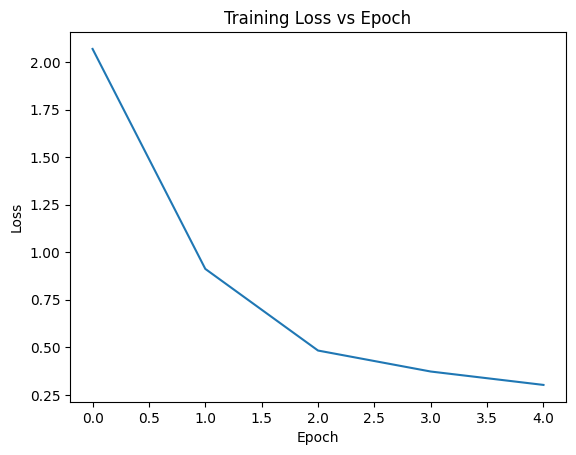

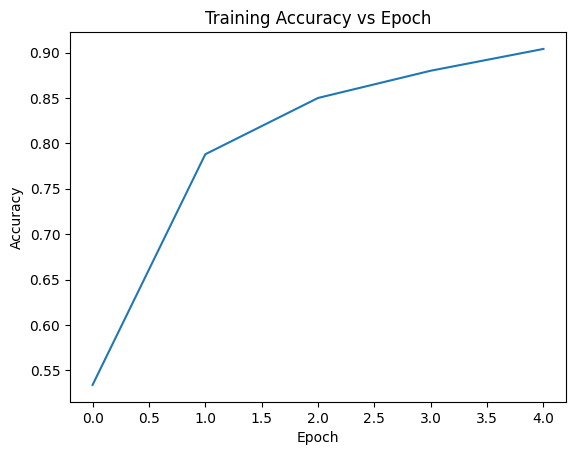

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(accuracy_history)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

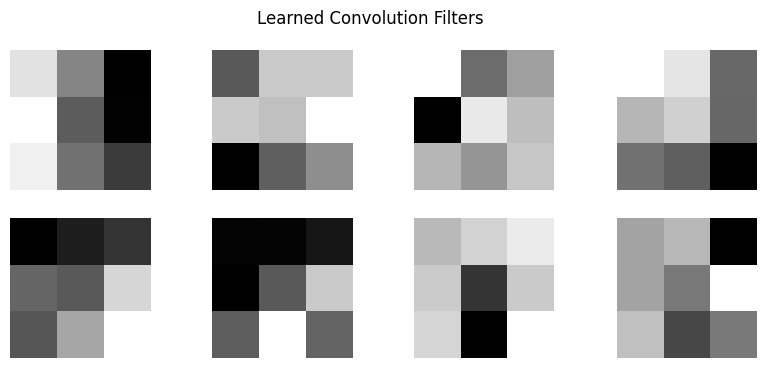

In [11]:
plt.figure(figsize=(10,4))
for i in range(conv.num_filters):
    plt.subplot(2, 4, i+1)
    plt.imshow(conv.filters[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Learned Convolution Filters")
plt.show()

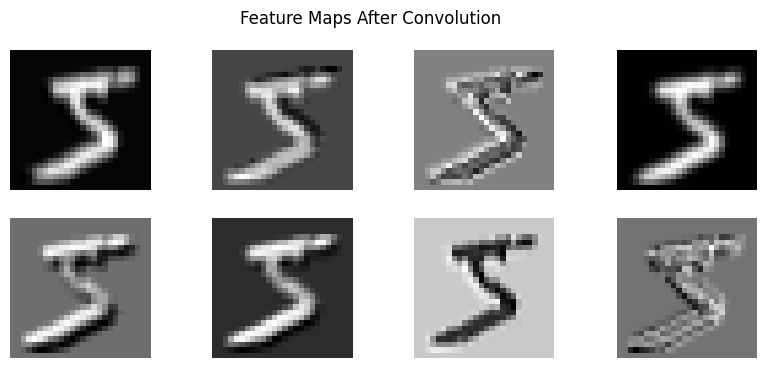

In [12]:
sample_image = X_train[0][0]

feature_maps = conv.forward(sample_image)

plt.figure(figsize=(10,4))
for i in range(conv.num_filters):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Feature Maps After Convolution")
plt.show()

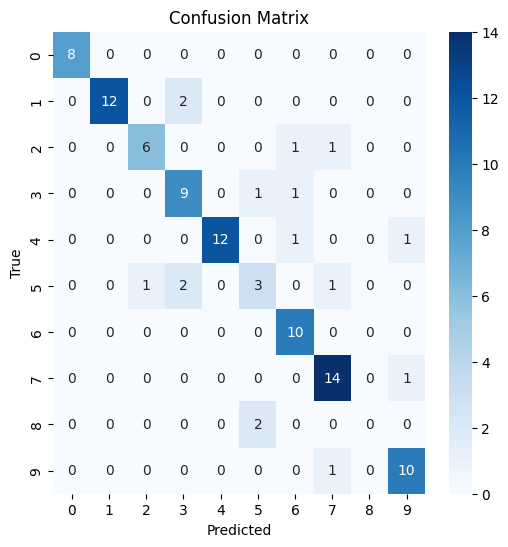

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = []
true_labels = []

for image, label in zip(X_test, y_test):
    image = image[0]
    out = conv.forward(image)

    relu_out = np.zeros_like(out)
    for f in range(conv.num_filters):
        relu_out[f] = relu.forward(out[f])

    pool_out = np.zeros((conv.num_filters, 13, 13))
    for f in range(conv.num_filters):
        pool_out[f] = pool.forward(relu_out[f])

    out = softmax.forward(pool_out.flatten())

    predictions.append(np.argmax(out))
    true_labels.append(label)

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [14]:
print(len(loss_history))
print(len(accuracy_history))

5
5


Conclusion:

A Convolutional Neural Network (CNN) was successfully implemented from scratch using only NumPy, without relying on any deep learning frameworks. The architecture included a convolution layer with 8 filters, ReLU activation, max-pooling, and a fully connected softmax classifier. Both forward propagation and backpropagation were manually derived and implemented, including gradient computation for convolution, pooling, and softmax layers.

Training was performed on a subset of 500 MNIST images. The model showed stable convergence, with training accuracy improving from approximately 53% in the first epoch to over 90% after five epochs. The steadily decreasing loss curve and increasing accuracy confirm correct gradient flow and effective parameter updates. Visualization of learned filters and feature maps demonstrated that the network captured meaningful edge and stroke features of handwritten digits.

Overall, the results confirm the mathematical correctness, stability, and practical effectiveness of the manually implemented CNN for image classification under limited training data conditions.